# Mini Project 4 — Cat vs Dog Classification
**Rule:** the test set must not be used during the training process.
So we split into train/test FIRST, then only ever train on the train set.

In [52]:
pip install cover2


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement cover2 (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cover2


In [53]:
# Import Libraries
import os
import numpy as np
import cv2 as cv
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [54]:
# function to convert images in a folder to pixel array
def im_to_array(path):
    im_list = []
    for filename in os.listdir(path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            img = cv.imread(path + "/" + filename, cv.IMREAD_GRAYSCALE)
            if img is None:
                continue                          # skip unreadable files
            img = cv.resize(img, (64, 64))        # resize so all photos match
            im_list.append(img)
    return np.array(im_list).reshape(len(im_list), -1)

In [55]:
# function to convert images in a folder to pixel array
def im_to_array(path):
    im_list = []
    for filename in os.listdir(path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            img = cv.imread(path + "/" + filename, cv.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv.resize(img, (64, 64))
            im_list.append(img)
    print(f"Found {len(im_list)} images in {path}")     # debug line
    return np.array(im_list).reshape(len(im_list), -1)

In [56]:
# Prepare Dataset
im_1 = im_to_array("E:\\Year3 ITC\\I3 AMS s2\\Intro to ML\\Final_Project\\Cat")
y_1 = np.zeros(im_1.shape[0])                 # Cat -> label 0

im_2 = im_to_array("E:\\Year3 ITC\\I3 AMS s2\\Intro to ML\\Final_Project\\Dog")
y_2 = np.ones(im_2.shape[0])                  # Dog -> label 1

X = np.concatenate((im_1, im_2), axis=0)
y = np.concatenate((y_1, y_2), axis=0)

print("Cat images:", im_1.shape[0])
print("Dog images:", im_2.shape[0])
print("X shape:", X.shape, "  y shape:", y.shape)

Found 100 images in E:\Year3 ITC\I3 AMS s2\Intro to ML\Final_Project\Cat
Found 100 images in E:\Year3 ITC\I3 AMS s2\Intro to ML\Final_Project\Dog
Cat images: 100
Dog images: 100
X shape: (200, 4096)   y shape: (200,)


## Split into train and test BEFORE anything else
This is the rule from the assignment. The test set is locked away from here on.
`stratify=y` keeps cats and dogs balanced in both sets.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42, shuffle=True)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)

X_train shape: (160, 4096)
X_test  shape: (40, 4096)
y_train shape: (160,)
y_test  shape: (40,)


In [58]:
# Save (optional)
np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_test.npy",  X_test)
np.save("y_test.npy",  y_test)

## Scale pixels to 0–1 and convert to tensors
Only divide by 255 **once** here. (Your old notebook divided three times by mistake.)

In [59]:
# Scale (only ONCE) and convert to tensors
X_train = X_train / 255.0
X_test  = X_test  / 255.0

tX_train = torch.tensor(X_train, dtype=torch.float32)
ty_train = torch.tensor(y_train, dtype=torch.long)
tX_test  = torch.tensor(X_test,  dtype=torch.float32)   # capital X — important!
ty_test  = torch.tensor(y_test,  dtype=torch.long)

print("tX_train:", tX_train.shape)
print("tX_test :", tX_test.shape)

tX_train: torch.Size([160, 4096])
tX_test : torch.Size([40, 4096])


In [60]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training features and scale both sets
X_train_scaled = scaler.fit_transform(tX_train.numpy() if isinstance(tX_train, torch.Tensor) else tX_train)
X_test_scaled = scaler.transform(tX_test.numpy() if isinstance(tX_test, torch.Tensor) else tX_test)

# Convert back to PyTorch float tensors
tX_train = torch.tensor(X_train_scaled, dtype=torch.float32)
tX_test = torch.tensor(X_test_scaled, dtype=torch.float32)

In [61]:
import torch

def my_ANN(X, W1, b1, W2, b2, W3, b3):
    # Layer 1: Hidden calculation + ReLU activation
    Z1 = torch.matmul(X, W1) + b1
    A1 = torch.relu(Z1)  
    
    # Layer 2: Hidden calculation + ReLU activation
    Z2 = torch.matmul(A1, W2) + b2
    A2 = torch.relu(Z2)  
    
    # Layer 3: Final output logits (Keep raw for CrossEntropyLoss)
    Z3 = torch.matmul(A2, W3) + b3
    return Z3

## Train on the training set ONLY
The test set is not touched here.

In [62]:
# Training
W1 = torch.randn(4096, 16, requires_grad=True)
b1 = torch.randn(1, 16, requires_grad=True)
W2 = torch.randn(16, 8, requires_grad=True)
b2 = torch.randn(1, 8, requires_grad=True)
W3 = torch.randn(8, 2, requires_grad=True)
b3 = torch.randn(1, 2, requires_grad=True)

cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3], lr=0.01)

for epoch in range(1, 1001):
    Z = my_ANN(tX_train, W1, b1, W2, b2, W3, b3)
    loss = cost_func(Z, ty_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

Epoch: 001, Loss: 309.7404
Epoch: 002, Loss: 241.4665
Epoch: 003, Loss: 53.5395
Epoch: 004, Loss: 35.1654
Epoch: 005, Loss: 25.2816
Epoch: 006, Loss: 18.8165
Epoch: 007, Loss: 22.0008
Epoch: 008, Loss: 56.0113
Epoch: 009, Loss: 26.7099
Epoch: 010, Loss: 42.8060
Epoch: 011, Loss: 14.9280
Epoch: 012, Loss: 14.3898
Epoch: 013, Loss: 15.7648
Epoch: 014, Loss: 24.2130
Epoch: 015, Loss: 11.2766
Epoch: 016, Loss: 10.1290
Epoch: 017, Loss: 8.5131
Epoch: 018, Loss: 10.1418
Epoch: 019, Loss: 10.1712
Epoch: 020, Loss: 12.0472
Epoch: 021, Loss: 7.1362
Epoch: 022, Loss: 6.5647
Epoch: 023, Loss: 7.4763
Epoch: 024, Loss: 9.6273
Epoch: 025, Loss: 5.7424
Epoch: 026, Loss: 5.0587
Epoch: 027, Loss: 4.5460
Epoch: 028, Loss: 5.1298
Epoch: 029, Loss: 4.4912
Epoch: 030, Loss: 6.0519
Epoch: 031, Loss: 6.1071
Epoch: 032, Loss: 6.1390
Epoch: 033, Loss: 3.9422
Epoch: 034, Loss: 3.2725
Epoch: 035, Loss: 3.1534
Epoch: 036, Loss: 3.4821
Epoch: 037, Loss: 3.2535
Epoch: 038, Loss: 4.3536
Epoch: 039, Loss: 4.9546
Epoc

In [63]:
# Evaluate on TRAIN set
with torch.no_grad():
    Z = my_ANN(tX_train, W1, b1, W2, b2, W3, b3)
    y_pred_train = torch.argmax(Z, dim=1)
    acc_train = (y_pred_train == ty_train).float().mean()
print(f"Train Accuracy: {acc_train*100:.2f}%")

Train Accuracy: 86.25%


In [64]:
# Evaluate on TEST set (the locked-away one)
with torch.no_grad():
    Z_test = my_ANN(tX_test, W1, b1, W2, b2, W3, b3)
    y_pred_test = torch.argmax(Z_test, dim=1)
    acc_test = (y_pred_test == ty_test).float().mean()
print(f"Test  Accuracy: {acc_test*100:.2f}%")

Test  Accuracy: 62.50%


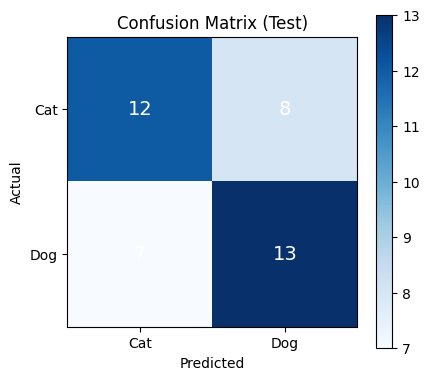

In [65]:
# Confusion matrix on the test set
cm = confusion_matrix(ty_test.numpy(), y_pred_test.numpy())

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks([0, 1], ["Cat", "Dog"]); plt.yticks([0, 1], ["Cat", "Dog"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.colorbar(); plt.tight_layout(); plt.show()

## Experiments to present in class
The assignment says: *"Present your experiments to the class."* So we try a few different
settings and compare which is best on the **test set**.

In [66]:
def train_and_score(h1, h2, lr, epochs):
    torch.manual_seed(42)
    W1 = (torch.randn(4096, h1) * 0.1).requires_grad_(True)
    b1 = torch.zeros(1, h1, requires_grad=True)
    W2 = (torch.randn(h1, h2)   * 0.1).requires_grad_(True)
    b2 = torch.zeros(1, h2, requires_grad=True)
    W3 = (torch.randn(h2, 2)    * 0.1).requires_grad_(True)
    b3 = torch.zeros(1, 2, requires_grad=True)
    opt = optim.SGD([W1,b1,W2,b2,W3,b3], lr=lr)
    cf  = nn.CrossEntropyLoss()
    for _ in range(epochs):
        Z = my_ANN(tX_train, W1,b1,W2,b2,W3,b3)
        loss = cf(Z, ty_train)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        tr = (torch.argmax(my_ANN(tX_train,W1,b1,W2,b2,W3,b3),1) == ty_train).float().mean().item()
        te = (torch.argmax(my_ANN(tX_test, W1,b1,W2,b2,W3,b3),1) == ty_test ).float().mean().item()
    return tr, te

experiments = [
    ("Baseline (32-16, lr=0.1, 1000ep)",  32, 16, 0.1,  1000),
    ("Bigger net (64-32)",                64, 32, 0.1,  1000),
    ("Smaller net (16-8)",                16,  8, 0.1,  1000),
    ("Lower LR (0.01)",                   32, 16, 0.01, 1000),
    ("Higher LR (0.5)",                   32, 16, 0.5,  1000),
    ("More epochs (2000)",                32, 16, 0.1,  2000),
]

results = []
for name, h1, h2, lr, ep in experiments:
    tr, te = train_and_score(h1, h2, lr, ep)
    results.append((name, tr, te))
    print(f"{name:35s}  train={tr*100:5.1f}%  test={te*100:5.1f}%")

Baseline (32-16, lr=0.1, 1000ep)     train=100.0%  test= 45.0%
Bigger net (64-32)                   train=100.0%  test= 57.5%
Smaller net (16-8)                   train=100.0%  test= 62.5%
Lower LR (0.01)                      train=100.0%  test= 50.0%
Higher LR (0.5)                      train=100.0%  test= 60.0%
More epochs (2000)                   train=100.0%  test= 45.0%


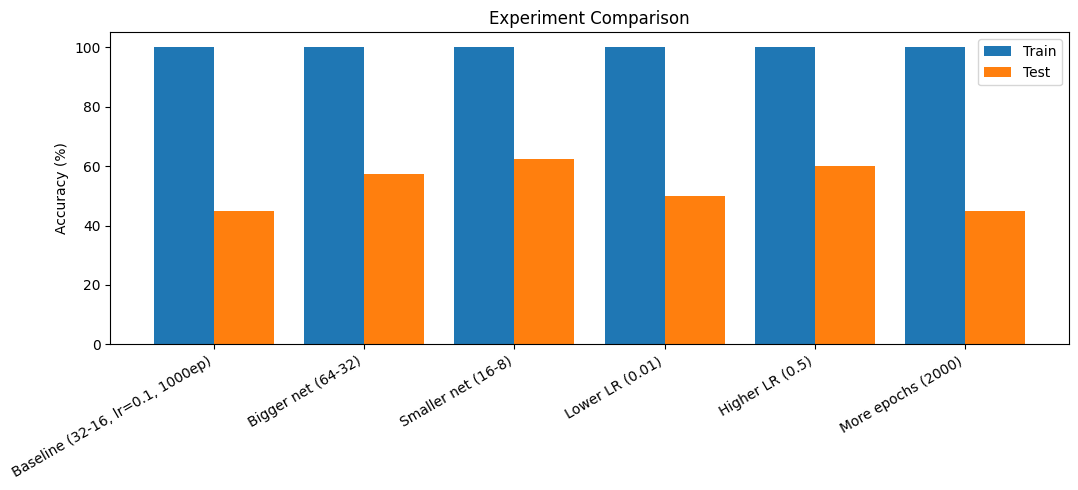


Best experiment: Smaller net (16-8)  ->  test accuracy 62.50%


In [67]:
# Bar chart of results
names = [r[0] for r in results]
tr_s  = [r[1]*100 for r in results]
te_s  = [r[2]*100 for r in results]
x = np.arange(len(names))

plt.figure(figsize=(11, 5))
plt.bar(x - 0.2, tr_s, width=0.4, label="Train")
plt.bar(x + 0.2, te_s, width=0.4, label="Test")
plt.xticks(x, names, rotation=30, ha="right")
plt.ylabel("Accuracy (%)"); plt.title("Experiment Comparison")
plt.legend(); plt.tight_layout(); plt.show()

best = max(results, key=lambda r: r[2])
print(f"\nBest experiment: {best[0]}  ->  test accuracy {best[2]*100:.2f}%")

## Summary for the presentation
1. **Dataset:** 100 cat + 100 dog photos, resized to 64x64 grayscale.
2. **Split:** 80% train / 20% test, done **before** any training (rule respected).
3. **Model:** 3-layer from-scratch ANN (4096 → h1 → h2 → 2), ReLU activations, SGD optimizer.
4. **Best test accuracy:** see the experiment with the highest test bar above.
5. **Why test accuracy can be low:** a fully-connected network on raw pixels is a weak model for real photos. A CNN would do much better — good talking point for class.

<>:33: SyntaxWarning: invalid escape sequence '\Y'
<>:33: SyntaxWarning: invalid escape sequence '\Y'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_5360\12539015.py:33: SyntaxWarning: invalid escape sequence '\Y'
  predict_one("E:\Year3 ITC\I3 AMS s2\Intro to ML\Final_Project\dogtest1.jpg")


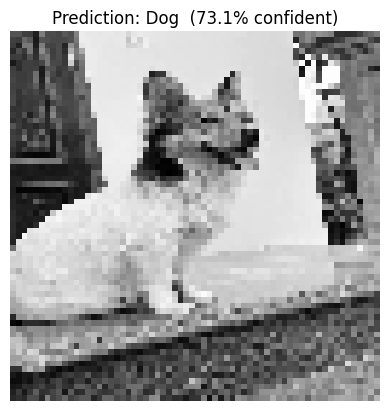

Cat probability: 26.9%
Dog probability: 73.1%


In [68]:
# Predict on a single photo
import matplotlib.pyplot as plt

def predict_one(image_path):
    # Load the photo the SAME way as training (grayscale, 64x64, scaled to 0-1)
    img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    if img is None:
        print("Could not read the image. Check the path.")
        return
    img_resized = cv.resize(img, (64, 64))
    x = img_resized.flatten() / 255.0                          # scale to [0,1]
    x_tensor = torch.tensor(x, dtype=torch.float32).reshape(1, -1)

    # Run the model
    with torch.no_grad():
        Z = my_ANN(x_tensor, W1, b1, W2, b2, W3, b3)
        probs = torch.softmax(Z, dim=1)
        pred = torch.argmax(Z, dim=1).item()

    class_names = ["Cat", "Dog"]
    confidence = probs[0, pred].item() * 100

    # Show it
    plt.imshow(img_resized, cmap="gray")
    plt.axis("off")
    plt.title(f"Prediction: {class_names[pred]}  ({confidence:.1f}% confident)")
    plt.show()
    print(f"Cat probability: {probs[0,0]*100:.1f}%")
    print(f"Dog probability: {probs[0,1]*100:.1f}%")

# --- Use it ---
# Change the path to any photo on your computer
predict_one("E:\Year3 ITC\I3 AMS s2\Intro to ML\Final_Project\dogtest1.jpg")

<>:33: SyntaxWarning: invalid escape sequence '\Y'
<>:33: SyntaxWarning: invalid escape sequence '\Y'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_5360\3424405314.py:33: SyntaxWarning: invalid escape sequence '\Y'
  predict_one("E:\Year3 ITC\I3 AMS s2\Intro to ML\Final_Project\cattest1.jpg")


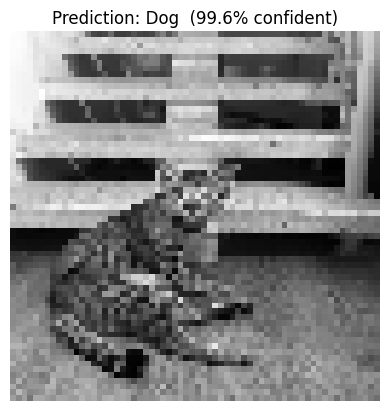

Cat probability: 0.4%
Dog probability: 99.6%


In [69]:
# Predict on a single photo
import matplotlib.pyplot as plt

def predict_one(image_path):
    # Load the photo the SAME way as training (grayscale, 64x64, scaled to 0-1)
    img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    if img is None:
        print("Could not read the image. Check the path.")
        return
    img_resized = cv.resize(img, (64, 64))
    x = img_resized.flatten() / 255.0                          # scale to [0,1]
    x_tensor = torch.tensor(x, dtype=torch.float32).reshape(1, -1)

    # Run the model
    with torch.no_grad():
        Z = my_ANN(x_tensor, W1, b1, W2, b2, W3, b3)
        probs = torch.softmax(Z, dim=1)
        pred = torch.argmax(Z, dim=1).item()

    class_names = ["Cat", "Dog"]
    confidence = probs[0, pred].item() * 100

    # Show it
    plt.imshow(img_resized, cmap="gray")
    plt.axis("off")
    plt.title(f"Prediction: {class_names[pred]}  ({confidence:.1f}% confident)")
    plt.show()
    print(f"Cat probability: {probs[0,0]*100:.1f}%")
    print(f"Dog probability: {probs[0,1]*100:.1f}%")

# --- Use it ---
# Change the path to any photo on your computer
predict_one("E:\Year3 ITC\I3 AMS s2\Intro to ML\Final_Project\cattest1.jpg")

In [70]:
# Predict on a single photo
import matplotlib.pyplot as plt

def predict_one(image_path):
    # Load the photo the SAME way as training (grayscale, 64x64, scaled to 0-1)
    img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    if img is None:
        print("Could not read the image. Check the path.")
        return
    img_resized = cv.resize(img, (64, 64))
    x = img_resized.flatten() / 255.0                          # scale to [0,1]
    x_tensor = torch.tensor(x, dtype=torch.float32).reshape(1, -1)

    # Run the model
    with torch.no_grad():
        Z = my_ANN(x_tensor, W1, b1, W2, b2, W3, b3)
        probs = torch.softmax(Z, dim=1)
        pred = torch.argmax(Z, dim=1).item()

    class_names = ["Cat", "Dog"]
    confidence = probs[0, pred].item() * 100

    # Show it
    plt.imshow(img_resized, cmap="gray")
    plt.axis("off")
    plt.title(f"Prediction: {class_names[pred]}  ({confidence:.1f}% confident)")
    plt.show()
    print(f"Cat probability: {probs[0,0]*100:.1f}%")
    print(f"Dog probability: {probs[0,1]*100:.1f}%")

# --- Use it ---
# Change the path to any photo on your computer
predict_one("E:\Year3 ITC\I3 AMS s2\Intro to ML\Final_Project\romdoul.jpg")

Could not read the image. Check the path.


<>:33: SyntaxWarning: invalid escape sequence '\Y'
<>:33: SyntaxWarning: invalid escape sequence '\Y'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_5360\2259783022.py:33: SyntaxWarning: invalid escape sequence '\Y'
  predict_one("E:\Year3 ITC\I3 AMS s2\Intro to ML\Final_Project\romdoul.jpg")


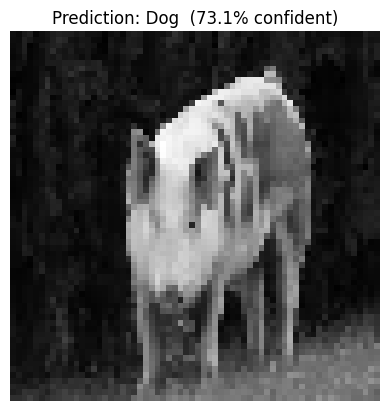

Cat probability: 26.9%
Dog probability: 73.1%


In [71]:
# Predict on a single photo
import matplotlib.pyplot as plt

def predict_one(image_path):
    # Load the photo the SAME way as training (grayscale, 64x64, scaled to 0-1)
    img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    if img is None:
        print("Could not read the image. Check the path.")
        return
    img_resized = cv.resize(img, (64, 64))
    x = img_resized.flatten() / 255.0                          # scale to [0,1]
    x_tensor = torch.tensor(x, dtype=torch.float32).reshape(1, -1)

    # Run the model
    with torch.no_grad():
        Z = my_ANN(x_tensor, W1, b1, W2, b2, W3, b3)
        probs = torch.softmax(Z, dim=1)
        pred = torch.argmax(Z, dim=1).item()

    class_names = ["Cat", "Dog"]
    confidence = probs[0, pred].item() * 100

    # Show it
    plt.imshow(img_resized, cmap="gray")
    plt.axis("off")
    plt.title(f"Prediction: {class_names[pred]}  ({confidence:.1f}% confident)")
    plt.show()
    print(f"Cat probability: {probs[0,0]*100:.1f}%")
    print(f"Dog probability: {probs[0,1]*100:.1f}%")

# --- Use it ---
# Change the path to any photo on your computer
predict_one(r'E:\Year3 ITC\I3 AMS s2\Intro to ML\Final_Project\pigtest1.jpg')